# Control systems development

In [403]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct


np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

## Longitudinal system

In [404]:
longitudinal_linear_matrices = np.load("longitudinal_linear.npz")
A = longitudinal_linear_matrices["A"]
B = longitudinal_linear_matrices["B"]
C = longitudinal_linear_matrices["C"]
D = longitudinal_linear_matrices["D"]

longitudinal_linear = ct.StateSpace(A, B, C, D)

### PID controller

In [405]:
K = np.zeros((1, 3))

P_gain = 0.5
D_gain = 0.1

K[0, 2] = P_gain
K[0, 1] = D_gain

print(K)

longitudinal_controller = ct.StateSpace(np.zeros((1,1)), np.zeros((1, 3)), np.zeros((1, 1)), K)

[[0.  0.1 0.5]]


[   0.279   -1.828 -131.22     0.   ]
[[0.  0.1 0.5]]
[[  0.      0.      0.028   0.139]
 [  0.      0.     -0.183  -0.914]
 [  0.      0.    -13.122 -65.61 ]
 [  0.      0.      0.      0.   ]]


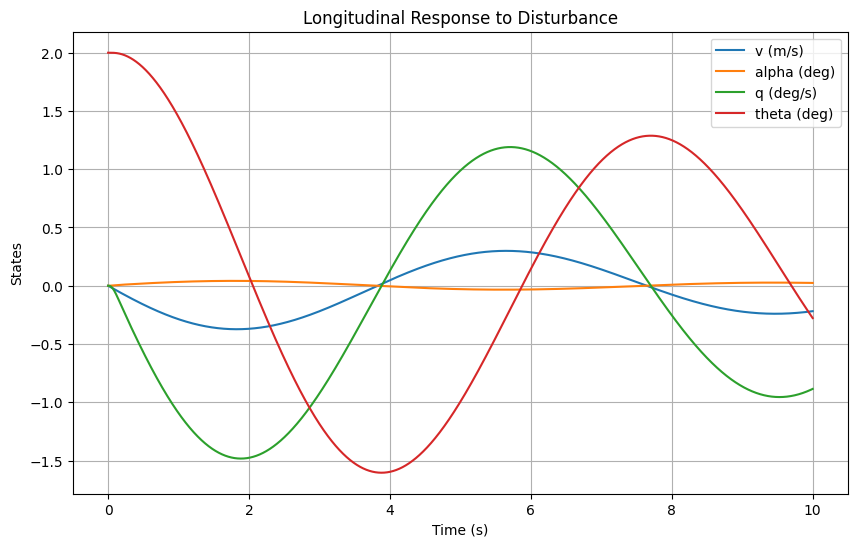

[-0.001  0.     0.    -0.   ]


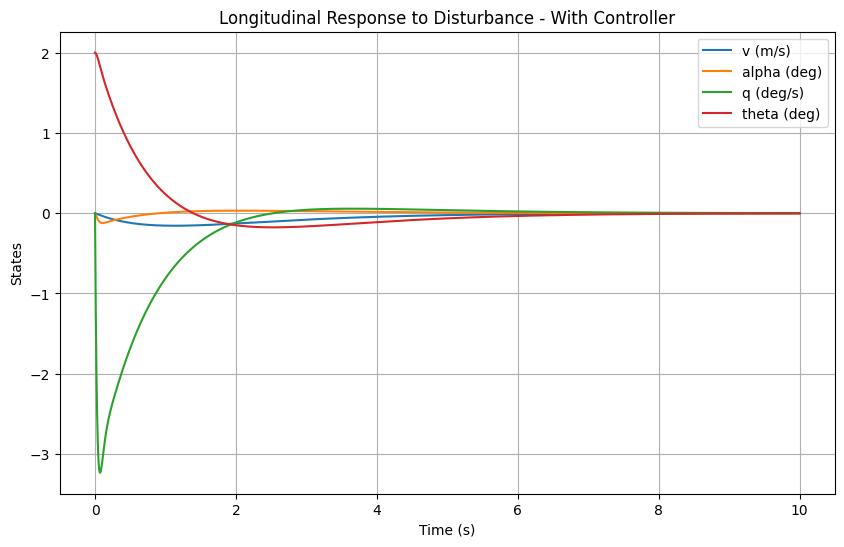

[[ 0.    -0.    -0.001 ... -0.001 -0.001 -0.001]
 [ 0.    -0.    -0.    ...  0.     0.     0.   ]
 [ 0.    -0.002 -0.004 ...  0.     0.     0.   ]
 [ 0.035  0.035  0.035 ... -0.    -0.    -0.   ]]


In [406]:
# run a simulation, where system has to stabilize a wind gust (2 degree pitch up disturbance)
print(B)
print(K)

#make B a column vector
B = B.reshape(-1, 1)

print(B@K@C)
longitudinal_feedback = ct.StateSpace(A + B @ K @ C, np.zeros((4, 1)), np.eye(4), np.zeros((4, 1)))

# start with the following state: 2 degree pitch up, all other states zero
x0 = np.array([0, 0, 0, 2 * np.pi / 180])
t = np.linspace(0, 10, 10000)

# no controller input, just see how the system responds to the initial condition
t, y, x = ct.forced_response(longitudinal_linear, T=t, U=np.zeros_like(t), X0=x0, return_states = True)
# plot 
plt.figure(figsize=(10, 6))
plt.plot(t, x[0, :], label="v (m/s)")
plt.plot(t, x[1, :] * 180 / np.pi, label="alpha (deg)")
plt.plot(t, x[2, :] * 180 / np.pi, label="q (deg/s)")
plt.plot(t, x[3, :] * 180 / np.pi, label="theta (deg)")
plt.xlabel("Time (s)")
plt.ylabel("States")
plt.title("Longitudinal Response to Disturbance")
plt.legend()
plt.grid()
plt.show()


t, y, x = ct.forced_response(longitudinal_feedback, T=t, U=np.zeros_like(t), X0=x0, return_states = True)

# steady state:
print(x[:, -1])

# plot 
plt.figure(figsize=(10, 6))
plt.plot(t, x[0, :], label="v (m/s)")
plt.plot(t, x[1, :] * 180 / np.pi, label="alpha (deg)")
plt.plot(t, x[2, :] * 180 / np.pi, label="q (deg/s)")
plt.plot(t, x[3, :] * 180 / np.pi, label="theta (deg)")
plt.xlabel("Time (s)")
plt.ylabel("States")
plt.title("Longitudinal Response to Disturbance - With Controller")
plt.legend()
plt.grid()
plt.show()

print(x)